In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


In [5]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)


Running on: cpu


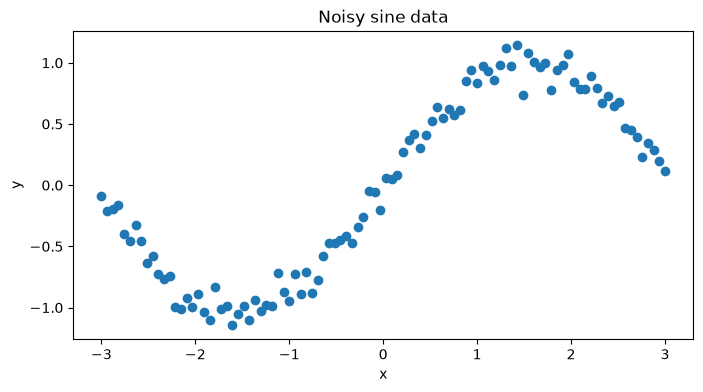

Final weight: 0.3390271203787366
Final bias: -0.017600294515841334
Final loss: 0.19550600956143946


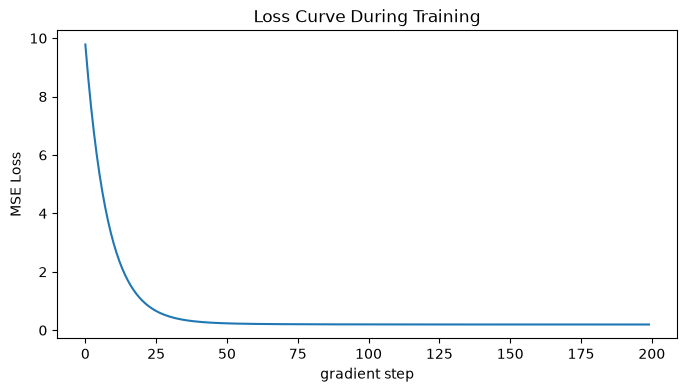

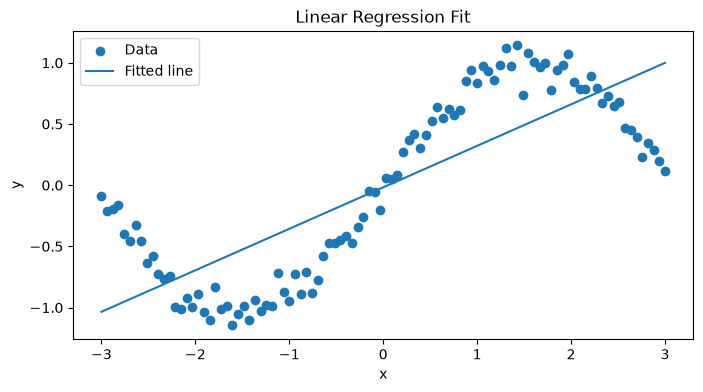

In [6]:
# Generate toy data
x = np.linspace(-3, 3, 100)

noise = np.random.normal(0, 0.1, 100)
y = np.sin(x) + noise

# Plot data
plt.figure(figsize=(8, 4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy sine data")
plt.show()


# Initialize parameters
w = np.random.randn()
b = np.random.randn()

# Training settings
lr = 0.01
n_steps = 200

losses = []

# Gradient descent loop
for i in range(n_steps):
    # Prediction
    y_hat = w * x + b

    # Loss (MSE)
    loss = np.mean((y_hat - y) ** 2)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Updating parameters
    w -= lr * dw
    b -= lr * db

    # Record loss
    losses.append(loss)

print("Final weight:", w)
print("Final bias:", b)
print("Final loss:", loss)

# Plot loss curve

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("gradient step")
plt.ylabel("MSE Loss")
plt.title("Loss Curve During Training")
plt.show()

# Plot fitted line with data

plt.figure(figsize=(8, 4))

plt.scatter(x, y, label="Data")

# fitted line
y_pred = w * x + b
plt.plot(x, y_pred, label="Fitted line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

x shape: (100, 1)
y shape: (100, 1)
Final loss with tanh: 0.023476316517891917


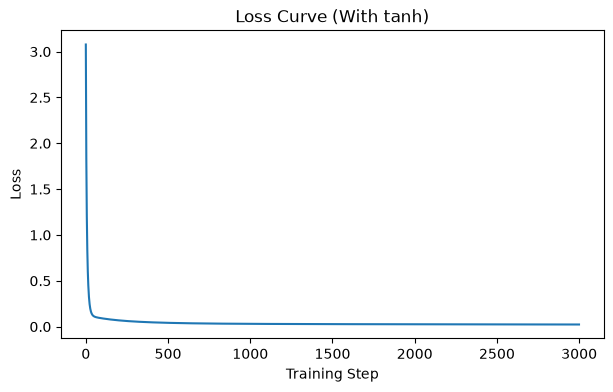

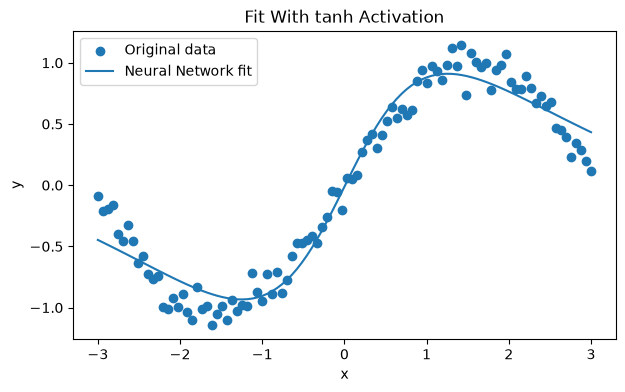

Final loss without tanh: 0.19545179713962046


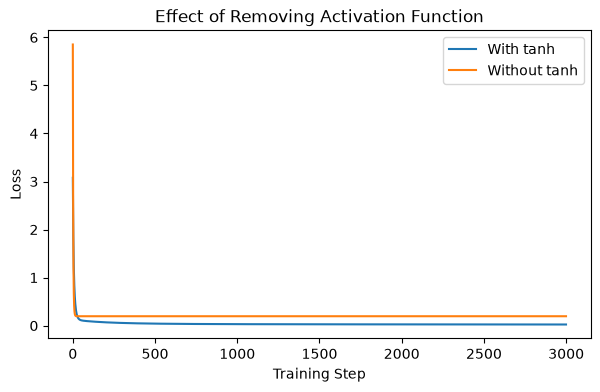

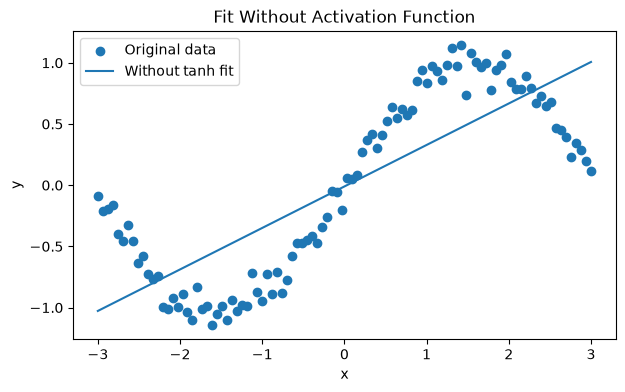

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# Ensure correct data shape


x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print("x shape:", x.shape)
print("y shape:", y.shape)



# Part 1.2: Hidden layers and activations
# 1 input - 8 hidden neurons - 1 output



# Initialise parameters
np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []



# Training with tanh activation

for step in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)

    y_hat = h @ W2 + b2

    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)


    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    # tanh derivative
    dz1 = dh * (1 - h**2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2


print("Final loss with tanh:", losses[-1])



# Plot loss curve


plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss Curve (With tanh)")
plt.show()



# Plot final fit with tanh

z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2


plt.figure(figsize=(7,4))
plt.scatter(x, y, label="Original data")
plt.plot(x, y_hat, label="Neural Network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit With tanh Activation")
plt.legend()
plt.show()




# Train again without tanh


np.random.seed(42)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

losses_linear = []


for step in range(3000):

    # Forward pass without activation
    z1 = x @ W1 + b1
    h = z1

    y_hat = h @ W2 + b2


    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses_linear.append(loss)


    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    # derivative of linear activation = 1
    dz1 = dh

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2


print("Final loss without tanh:", losses_linear[-1])



# Compare losses


plt.figure(figsize=(7,4))
plt.plot(losses, label="With tanh")
plt.plot(losses_linear, label="Without tanh")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Effect of Removing Activation Function")
plt.legend()
plt.show()




# Final fit without tanh


z1 = x @ W1 + b1
y_hat_linear = z1 @ W2 + b2


plt.figure(figsize=(7,4))
plt.scatter(x, y, label="Original data")
plt.plot(x, y_hat_linear, label="Without tanh fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit Without Activation Function")
plt.legend()
plt.show()

1. When the activation function is removed, every layer becomes a linear transformation. Therefore, the network cannot learn more complex curves than the single neuron model. For example, the network becomes:

y= (xW, + b,) W + b
y= xW,W + b,W + b

Since W,W and b,W + b are just new weights and biases, the whole network can be rewritten as:
y=xW+b

2. The 8 hidden neurons act as different feature detectors. Each neuron changes the input x into a different nonlinear feature through the tanh activation.

3. Backpropagation is the process of calculating how much each network parameter contributed to the error by applying chain rule from the output layer backward, allowing the weights and biases to be updated to reduce the loss.

C:\Users\marfo\AppData\Local\Temp\ipykernel_7020\2797744031.py:31: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y)**2)
C:\Users\marfo\AppData\Local\Temp\ipykernel_7020\2797744031.py:41: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\marfo\AppData\Local\Temp\ipykernel_7020\2797744031.py:43: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - h**2)


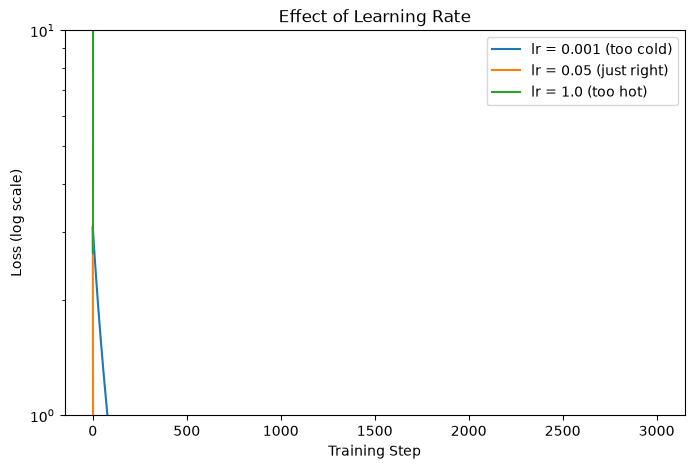

In [12]:
import numpy as np
import matplotlib.pyplot as plt



# Training function
def train_toy(lr, steps=3000):

    # Reset weights for fair comparison
    np.random.seed(42)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []


    for step in range(steps):

        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)

        y_hat = h @ W2 + b2


        # Loss
        loss = np.mean((y_hat - y)**2)
        losses.append(loss)


        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T

        dz1 = dh * (1 - h**2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)


        # Update parameters
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2


    return losses




# Train with different learning rates
loss_cold = train_toy(lr=0.001, steps=3000)
loss_good = train_toy(lr=0.05, steps=3000)
loss_hot = train_toy(lr=1.0, steps=3000)




# Plot comparison
plt.figure(figsize=(8,5))

plt.plot(loss_cold, label="lr = 0.001 (too cold)")
plt.plot(loss_good, label="lr = 0.05 (just right)")
plt.plot(loss_hot, label="lr = 1.0 (too hot)")

plt.yscale("log")

plt.xlabel("Training Step")
plt.ylabel("Loss (log scale)")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

A very small learning rate makes learning slow bacause the weights modify by small amounts, making the loss to decrease eventually. 
An appropriate learning rate (0.05) allows the model to learn efficiently because updates are big enough to minimize the loss without overshooting.
A very large learning rate causes the loss to explode because the weight updates become too big and repeatedly shoot over the best values instead of moving toward them.

In [15]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import TensorDataset, DataLoader
# Load obesity dataset
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

obesity = pd.read_csv(OBESITY_URL)

print(obesity.head())
print(obesity.shape)



# Encode categorical variables
# Convert yes/no columns to 0/1

binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    obesity[col] = obesity[col].map({
        "yes": 1,
        "no": 0
    })


# Encode categorical columns

categorical_cols = [
    "Gender",
    "MTRANS",
    "CAEC",
    "CALC"
]

for col in categorical_cols:
    encoder = LabelEncoder()
    obesity[col] = encoder.fit_transform(obesity[col])


# Encode target column

target_encoder = LabelEncoder()

obesity["NObeyesdad"] = target_encoder.fit_transform(
    obesity["NObeyesdad"]
)

# Split data 60/20/20
RANDOM_STATE = 42

X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)


# Convert to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)


y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.long
)


# Create DataLoaders
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

1. PyTorch's CrossEntropyLoss requires the target labels to be integer class indices because it internallly applies the softmax function and finds the negative log likelihood for the correct class. One hot encoding vectors are not required because PyTorch already handles the conversion internally.
2. Random forests are based on the decision trees that split data using feature thresholds, so the scale of the features does not affect the splitting decisions. Neural networks, however, depend on gradient descent to update weights.
3. Shuffle=True randomly changes the order of training samples at the beginning of each epoch. This prevents the model from learning patterns based on the order of the data and helps each mini-batch. It improves training stability and allows the neural network to generalize better.

In [16]:
import torch.nn as nn


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train.shape[1]

model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7
)

model = model.to(DEVICE)

print(model)



trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)


first_layer_params = input_dim * 64 + 64

print("First layer parameters:", first_layer_params)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3399
First layer parameters: 1088



1. Input (16 features) → Hidden Layer 1 (64 neurons) → Hidden Layer 2 (32 neurons) → Output (7 classes)
Layer 1: Input → Hidden Layer 1
Weights: 16 × 64 = 1024
Biases:64
Total parameters: 1024 + 64 = 1088

Layer 2: Hidden Layer 1 → Hidden Layer 2
Weights: 64 × 32 = 2048
Biases:32
Total parameters: 2048 + 32 = 2080

Layer 3: Hidden Layer 2 → Output Layer
Weights: 32 × 7 = 224
Biases: 7
Total parameters: 224 + 7 = 231
Total trainable parameters: 1088 + 2080 + 231 = 3399

PyTorch also reports 3399 trainable parameters, so the manual calculation matches the model's parameter count.
2. ReLU is prefered in deeper neural networks because it helps minimize the vanishing gradient problem. It allows positive values to pass through without shrinking them, which helps gradients flow better during training. It's computation is simple than tanh.
3. Without the ReLU activation functions, all layers would become linear transformations. A stack of linear layers can be combined into a single linear transformation, so the network would act like a linear model and would not be able to learn complex non-linear patterns in the data.

Epoch 1/50 | Train Loss: 0.0227 | Val Loss: 0.2853 | Train Acc: 0.9992 | Val Acc: 0.9194
Epoch 2/50 | Train Loss: 0.0215 | Val Loss: 0.2921 | Train Acc: 0.9984 | Val Acc: 0.9123
Epoch 3/50 | Train Loss: 0.0169 | Val Loss: 0.2868 | Train Acc: 1.0000 | Val Acc: 0.9171
Epoch 4/50 | Train Loss: 0.0154 | Val Loss: 0.2808 | Train Acc: 1.0000 | Val Acc: 0.9194
Epoch 5/50 | Train Loss: 0.0143 | Val Loss: 0.2881 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 6/50 | Train Loss: 0.0129 | Val Loss: 0.2960 | Train Acc: 1.0000 | Val Acc: 0.9100
Epoch 7/50 | Train Loss: 0.0127 | Val Loss: 0.2957 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 8/50 | Train Loss: 0.0116 | Val Loss: 0.2988 | Train Acc: 1.0000 | Val Acc: 0.9265
Epoch 9/50 | Train Loss: 0.0109 | Val Loss: 0.3017 | Train Acc: 1.0000 | Val Acc: 0.9218
Epoch 10/50 | Train Loss: 0.0094 | Val Loss: 0.2983 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 11/50 | Train Loss: 0.0085 | Val Loss: 0.3002 | Train Acc: 1.0000 | Val Acc: 0.9194
Epoch 12/50 | Train

C:\Users\marfo\AppData\Local\Temp\ipykernel_7020\2199103974.py:126: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7,4))


Epoch 22/50 | Train Loss: 0.0040 | Val Loss: 0.3269 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 23/50 | Train Loss: 0.0039 | Val Loss: 0.3257 | Train Acc: 1.0000 | Val Acc: 0.9218
Epoch 24/50 | Train Loss: 0.0037 | Val Loss: 0.3238 | Train Acc: 1.0000 | Val Acc: 0.9194
Epoch 25/50 | Train Loss: 0.0034 | Val Loss: 0.3301 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 26/50 | Train Loss: 0.0032 | Val Loss: 0.3281 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 27/50 | Train Loss: 0.0029 | Val Loss: 0.3261 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 28/50 | Train Loss: 0.0028 | Val Loss: 0.3301 | Train Acc: 1.0000 | Val Acc: 0.9242
Epoch 29/50 | Train Loss: 0.0026 | Val Loss: 0.3356 | Train Acc: 1.0000 | Val Acc: 0.9218
Epoch 30/50 | Train Loss: 0.0025 | Val Loss: 0.3354 | Train Acc: 1.0000 | Val Acc: 0.9194
Epoch 31/50 | Train Loss: 0.0023 | Val Loss: 0.3389 | Train Acc: 1.0000 | Val Acc: 0.9218
Epoch 32/50 | Train Loss: 0.0022 | Val Loss: 0.3413 | Train Acc: 1.0000 | Val Acc: 0.9194
Epoch 33/5

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

...

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

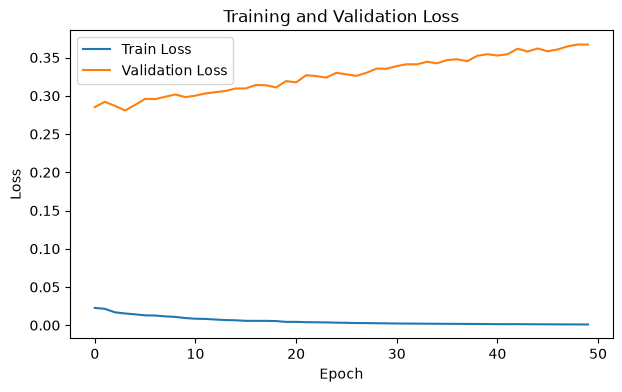

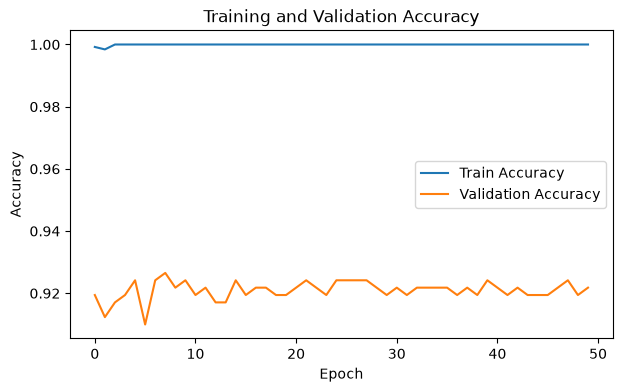

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


epochs = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0


for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0


    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == yb).sum().item()

        total += yb.size(0)



    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total


    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)


            logits = model(xb)

            loss = criterion(logits, yb)


            val_loss += loss.item()


            predictions = torch.argmax(logits, dim=1)

            val_correct += (predictions == yb).sum().item()

            val_total += yb.size(0)



    val_loss = val_loss / len(val_loader)

    val_accuracy = val_correct / val_total



    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)

    val_accuracies.append(val_accuracy)



    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "ffn_best.pt"
        )



    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    plt.figure(figsize=(7,4))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()



plt.figure(figsize=(7,4))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

1. The PyTorch training loop follows the same steps as the manual NumPy implementation:

- Forward pass:

```python
logits = model(xb)
loss = criterion(logits, yb)

1. The PyTorch training loop follows the same three steps as the manual NumPy implementation from Section 1.

Forward pass:
logits = model(xb.to(DEVICE))
loss = criterion(logits, yb.to(DEVICE))
This corresponds to the NumPy forward pass = 
z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2
loss = np.mean((y_hat - y)**2)

Gradient computation (backpropagation):
loss.backward()
This corresponds to the manual gradient calculations:
dW1, db1, dW2, db2


Parameter update:
optimizer.step()
This corresponds to the manual update rule:
W1 -= lr * dW1
b1 -= lr * db1
W2 -= lr * dW2
b2 -= lr * db2

2. The model shows signs of slight overfitting. At the end of training (epoch 50):

- Training accuracy = 1.0000 (100%)
- Validation accuracy = 0.9218 (92.18%)
- Training loss = 0.0205
- Validation loss = 0.2739

The training accuracy is much higher than the validation accuracy, showing that the model has learned the training data almost perfectly. However, the validation accuracy remains high at 92.18%, meaning the model still generalizes well. The increasing gap between training and validation performance indicates some overfitting, but it is not severe.

3. We call optimizer.zero_grad() before each batch because PyTorch accumulates gradients by default. If we do not clear the gradients, the gradients from previous batches will be added to the current batch's gradients. This causes incorrect parameter updates and can make the training process unstable because the optimizer is no longer using only the current batch's information.